Proyecto de regresion lineal con el Dataset de MKT Bancario 

In [144]:
%pip install pandas numpy matplotlib seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [145]:
import pandas as pd
import sklearn as sl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings


### Cargar el Dataset

In [146]:

df = pd.read_csv('bank-marketing-campaign-data.csv',sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Diccionario de Datos: Campaña de Marketing Bancario

Este conjunto de datos contiene información sobre campañas de marketing directo (llamadas telefónicas) de una institución bancaria portuguesa. El objetivo es predecir si el cliente suscribirá un depósito a plazo (variable `y`).

## 1. Datos Demográficos y Financieros del Cliente
| Variable | Descripción |
| :--- | :--- |
| **age** | Edad del cliente (numérico). |
| **job** | Tipo de trabajo (categórico: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown'). |
| **marital** | Estado civil (categórico: 'divorced', 'married', 'single', 'unknown'; nota: 'divorced' incluye viudo/a). |
| **education** | Nivel educativo (categórico: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown'). |
| **default** | ¿Tiene crédito en mora? (categórico: 'no', 'yes', 'unknown'). |
| **housing** | ¿Tiene préstamo para vivienda? (categórico: 'no', 'yes', 'unknown'). |
| **loan** | ¿Tiene un préstamo personal? (categórico: 'no', 'yes', 'unknown'). |

## 2. Información del Último Contacto
| Variable | Descripción |
| :--- | :--- |
| **contact** | Tipo de comunicación de contacto (categórico: 'cellular', 'telephone'). |
| **month** | Mes del último contacto del año (categórico: 'jan', 'feb', 'mar', ..., 'nov', 'dec'). |
| **day_of_week** | Último día de contacto de la semana (categórico: 'mon', 'tue', 'wed', 'thu', 'fri'). |
| **duration** | Duración del último contacto en segundos (numérico). **Nota importante:** Esta variable afecta mucho al objetivo (si es 0, y='no'). Solo se conoce al final de la llamada. |

## 3. Atributos de la Campaña
| Variable | Descripción |
| :--- | :--- |
| **campaign** | Número de contactos realizados durante esta campaña para este cliente (numérico). |
| **pdays** | Días transcurridos desde que el cliente fue contactado por última vez en una campaña anterior (numérico; 999 significa que no fue contactado previamente). |
| **previous** | Número de contactos realizados antes de esta campaña para este cliente (numérico). |
| **poutcome** | Resultado de la campaña de marketing anterior (categórico: 'failure', 'nonexistent', 'success'). |

## 4. Indicadores Socioeconómicos
| Variable | Descripción |
| :--- | :--- |
| **emp.var.rate** | Tasa de variación del empleo - indicador trimestral (numérico). |
| **cons.price.idx** | Índice de precios al consumidor - indicador mensual (numérico). |
| **cons.conf.idx** | Índice de confianza del consumidor - indicador mensual (numérico). |
| **euribor3m** | Tasa Euribor a 3 meses - indicador diario (numérico). |
| **nr.employed** | Número de empleados - indicador trimestral (numérico). |

## 5. Variable Objetivo (Target)
| Variable | Descripción |
| :--- | :--- |
| **y** | ¿Ha suscrito el cliente un depósito a plazo? (binario: 'yes', 'no'). |

### I.- Primer estudio del Dataset MKT Bank 

Tipo y cantidad de Valriables y Data Frame  

In [147]:
df.dtypes.value_counts()

str        11
int64       5
float64     5
Name: count, dtype: int64

In [148]:
print(type(df))

<class 'pandas.DataFrame'>


Revisión de las columnas del dataset 

In [149]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

Revisión de los datos nulos en le dataset

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### II.- Revisión de la información que aporta el dataset sobre la campaña. El objetivo final será poder predecir cuántos clientes serán futuros compradores de servicios del banco a largo plazo.

Revisión de los resultados de la campaña, con un análisis de la variable objetivo.

In [151]:
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [152]:
(df['y'].value_counts(normalize=True)*100).round(2)

y
no     88.73
yes    11.27
Name: proportion, dtype: float64

Revisión general de las variables del Dataset

In [153]:
df.dtypes
df.dtypes.value_counts()

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

str        11
int64       5
float64     5
Name: count, dtype: int64

In [154]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Al final de esta revisión, tengo la cuenta y los tipos de variables, y se que no hay valores nulos dentro de las columnas 

### III.- Revisión profunda de las variables categóricas y numéricas 

In [155]:
# Revisión de los tipos de variables para estudiar las posibles categóricas 
var_texto = df.select_dtypes(include=['str']).columns.tolist()
print("Posibles variables categoricas potenciales:")
print(var_texto)
var_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Variables numericas:")
print(var_numericas)

Posibles variables categoricas potenciales:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Variables numericas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


Revision de la variable pdays

In [156]:
# Extraer los valores únicos
valores_unicos = df['pdays'].unique()
print(f"Valores únicos para la variable '{'pdays'}':\n")
print(valores_unicos)

Valores únicos para la variable 'pdays':

[999   6   4   3   5   1   0  10   7   8   9  11   2  12  13  14  15  16
  21  17  18  22  25  26  19  27  20]


La variable "pdays" no aporta mucha información de la manera como se presenta en el dataset. Por lo tanto, se transformará en una variable categórica numérica que permita relacionarla con el resto de los datos. 

In [157]:
df['pdays_cat'] = np.where(df['pdays'] <= 60, 1, 0)
print(df['pdays_cat'].unique())

[0 1]


In [158]:
# Reemplazo definitivo de la columna 'y' por 'y_num'
if 'pdays' in df.columns:
    df.drop(columns=['pdays'], inplace=True)

# Imprimimos los nombres de todas las columnas para verificar que ya no existe 'y'


# Sacamos 'y' de la lista de variables de texto si todavía está ahí
if 'pdays_cat' in var_numericas:
    var_numericas.remove('pdays') 

print(df.columns)    

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'pdays_cat'],
      dtype='str')


In [159]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,pdays_cat
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


Revisión de la variable objetivo "y"

In [160]:
# Extraer los valores únicos
valores_unicos = df['y'].unique()
print(f"Valores únicos para la variable '{'y'}':\n")
print(valores_unicos)

Valores únicos para la variable 'y':

<StringArray>
['no', 'yes']
Length: 2, dtype: str


Transformación de la variable 'y' a un formato numérico para facilitar el análisis de correlación con el conjunto de variables cuantitativas.

In [161]:
y_num = 'y'
mapeo = {'yes': 1, 'no': 0}

# 3. Aplica la transformación reemplazando los datos en la misma columna
df[y_num] = df[y_num].map(mapeo)

# Imprimimos los primeros valores para verificar el cambio
print(df[y_num].head())

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64


In [162]:
# Reemplazo definitivo de la columna 'y' por 'y_num'
df.rename(columns={'y': 'y_num'}, inplace=True)

# Imprimimos los nombres de todas las columnas para verificar que ya no existe 'y'
print(df.columns)

# Sacamos 'y' de la lista de variables de texto si todavía está ahí
if 'y' in var_texto:
    var_texto.remove('y')

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y_num', 'pdays_cat'],
      dtype='str')


Voy a guardar todos estos cambios en un nuevo dataset para preservar el original con los menores cambios posibles por si es necesario utilizarlo nuevamente

In [163]:
new_dfile= 'nuevo_dataset.csv'
df.to_csv(new_dfile, index=False)

In [164]:
df_n = pd.read_csv('nuevo_dataset.csv')
df_n.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num,pdays_cat
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0


Tratamiento de los valores desconocidos 

In [165]:
# Contar cuántos 'unknown' hay en cada columna de texto
conteo_unknown = df_n[var_texto].apply(lambda x: (x == 'unknown').sum())

# Filtrar para mostrar solo las columnas que tienen al menos un 'unknown' y ordenarlas
conteo_unknown = conteo_unknown[conteo_unknown > 0].sort_values(ascending=False)

print("Cantidad de valores 'unknown' por columna:")
display(conteo_unknown)

Cantidad de valores 'unknown' por columna:


default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64

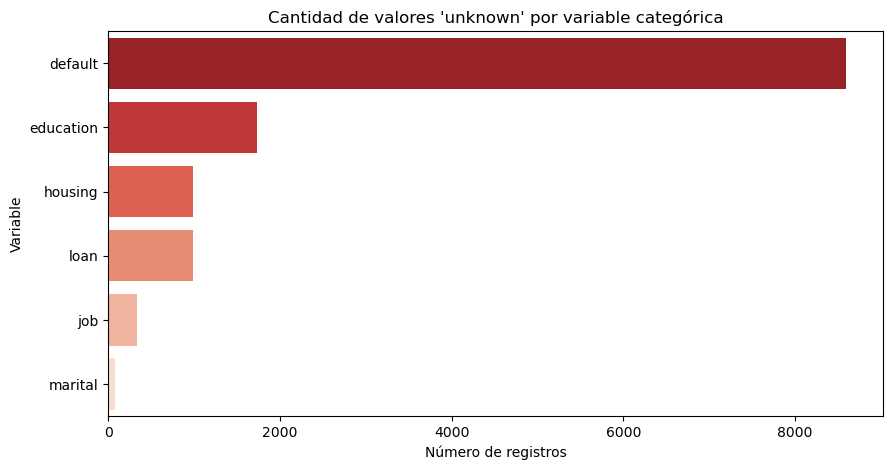

In [166]:
# Crear un gráfico de barras para visualizar los 'unknown'
_ = plt.figure(figsize=(10, 5))
_ = sns.barplot(x=conteo_unknown.values, y=conteo_unknown.index, hue=conteo_unknown.index, palette="Reds_r", legend=False)

_ = plt.title("Cantidad de valores 'unknown' por variable categórica")
_ = plt.xlabel("Número de registros")
_ = plt.ylabel("Variable")
_ = plt.show()

En este dataset, 'unknown' es en realidad una categoría dentro de algunas variables, porque no es que el dato se haya perdido, sino que en realidad no hay información sobre el cliente en ese aspecto.

Exploración de las variables con el fin de identificar patrones y tendencias.

Análisis univariante 

Revisión de las correlaciones del nuevo Dataset

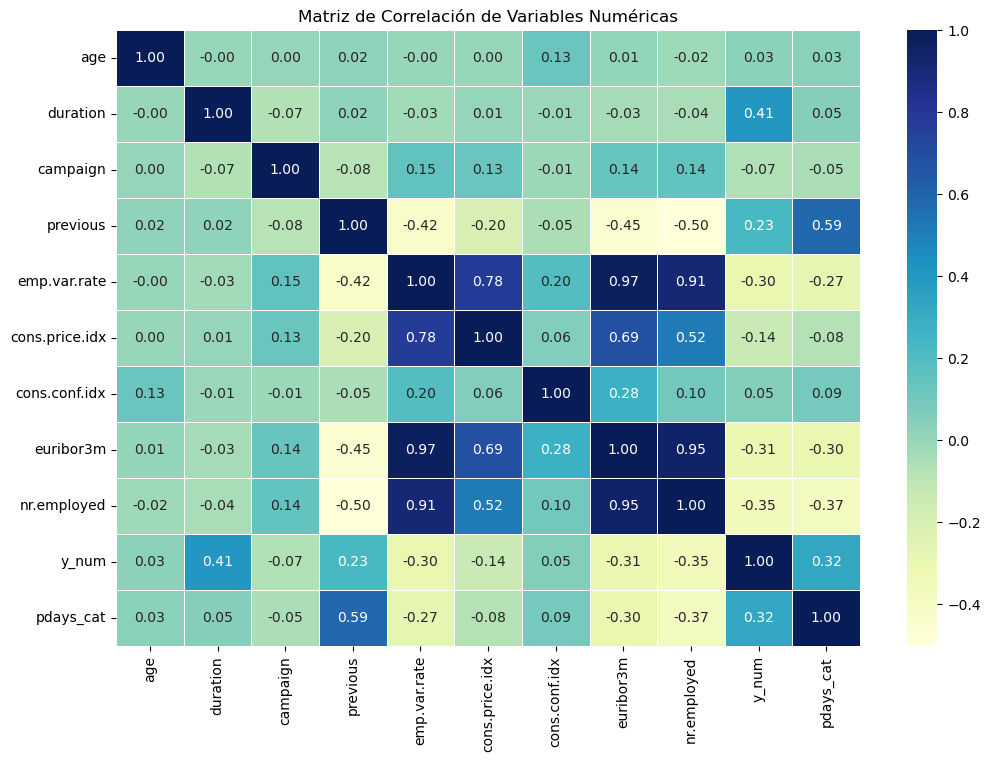

In [167]:
# Matriz de Correlación del nuevo Dataset_ =  
numerics = df_n.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerics.corr()

_ = plt.figure(figsize=(12, 8))
_ = sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
_ = plt.title('Matriz de Correlación de Variables Numéricas')
_ = plt.show()

Evaluación de dependencias entre variables para establecer los criterios del análisis exploratorio preliminar.

In [168]:
# Definimos la variable objetivo directamente
variable_objetivo = 'y_num'

# Filtramos solo columnas numéricas para evitar errores de cálculo
df_numerico = df_n.select_dtypes(include=[np.number])
correlaciones = df_numerico.corr()[variable_objetivo].drop(variable_objetivo)

positivas = correlaciones[correlaciones > 0].sort_values(ascending=False)
negativas = correlaciones[correlaciones < 0].sort_values(ascending=True)

print("GRUPO 1: CORRELACIONES POSITIVAS")

print("\nPROCENTAJE DE CORRELACION POR CADA VARIABLE POSITIVA ")
for variable, valor in positivas[positivas <= 0.5].items():
    print(f"{variable}: {valor:.2%}")
    
print("\nGRUPO 2: CORRELACIONES NEGATIVAS")

print("\nPROCENTAJE DE CORRELACION POR CADA VARIABLE NEGATIVA ")
for variable, valor in negativas[negativas >= -0.5].items():
    print(f"{variable}: {valor:.2%}")

GRUPO 1: CORRELACIONES POSITIVAS

PROCENTAJE DE CORRELACION POR CADA VARIABLE POSITIVA 
duration: 40.53%
pdays_cat: 32.49%
previous: 23.02%
cons.conf.idx: 5.49%
age: 3.04%

GRUPO 2: CORRELACIONES NEGATIVAS

PROCENTAJE DE CORRELACION POR CADA VARIABLE NEGATIVA 
nr.employed: -35.47%
euribor3m: -30.78%
emp.var.rate: -29.83%
cons.price.idx: -13.62%
campaign: -6.64%


Análisis visual de las correlaciones positivas y negativas en relación con la variable objetivo

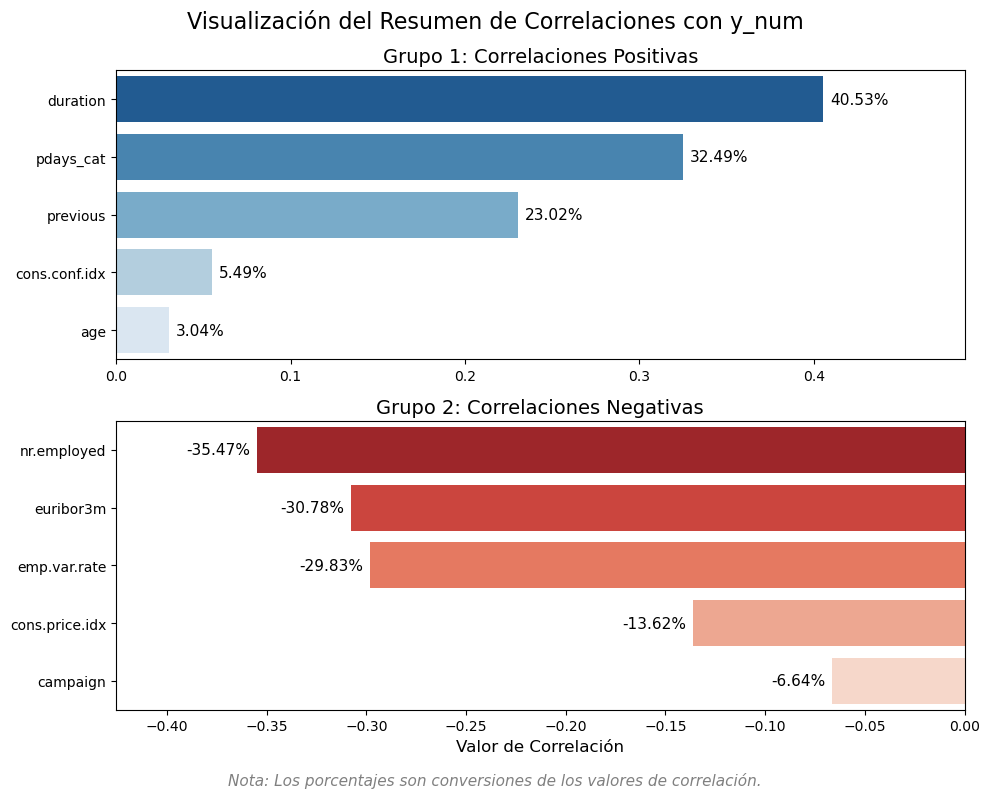

In [169]:
# En este gráfico espero ver las variables que pueden ayudar al proceso de decisión del cliente y las que podrían frenar el proceso de decisión.

df_numerico = df_n.select_dtypes(include=[np.number])
correlaciones = df_numerico.corr()[variable_objetivo].drop(variable_objetivo)

# Agrupar las correlaciones positivas y negativas 
positivas = correlaciones[correlaciones > 0].sort_values(ascending=False)
negativas = correlaciones[correlaciones < 0].sort_values(ascending=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
_ = fig.suptitle(f'Visualización del Resumen de Correlaciones con {variable_objetivo}', fontsize=16)

#Gráfico 1: Positivas
_ = sns.barplot(x=positivas.values, y=positivas.index, hue=positivas.index, palette="Blues_r", ax=axes[0], legend=False)
_ = axes[0].set_title("Grupo 1: Correlaciones Positivas", fontsize=14)
_ = axes[0].set_ylabel('')
_ = axes[0].set_xlabel('')
_ = axes[0].set_xlim(0, positivas.max() * 1.2)

# Etiquetas automáticas silenciadas con "_"
for container in axes[0].containers:
    _ = axes[0].bar_label(container, fmt=lambda x: f"{x*100:.2f}%", padding=5, fontsize=11)

# Gráfico 2: Negativas
_ = sns.barplot(x=negativas.values, y=negativas.index, hue=negativas.index, palette="Reds_r", ax=axes[1], legend=False)
_ = axes[1].set_title("Grupo 2: Correlaciones Negativas", fontsize=14)
_ = axes[1].set_ylabel('')
_ = axes[1].set_xlabel('Valor de Correlación', fontsize=12)
_ = axes[1].set_xlim(negativas.min() * 1.2, 0)

# Etiquetas automáticas silenciadas con "_"
for container in axes[1].containers:
    _ = axes[1].bar_label(container, fmt=lambda x: f"{x*100:.2f}%", padding=5, fontsize=11)

# Nota silenciada
_ = fig.text(0.5, 0.01, "Nota: Los porcentajes son conversiones de los valores de correlación.", ha='center', fontsize=11, style='italic', color='gray')

# Mostrar gráfico
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

Lo importante de este gráfico es que me permite tener una primera vista de las variables que probablemente sean relevantes, cuáles podrían ayudar al proceso de decisión y cuáles posiblemente frenen el proceso de adquisición de productos del banco.

Podemos identificar algunas tendencias claras en este gráfico: las variables macroeconómicas que reflejan la situación económica del país pueden influir de manera contraria a la decisión, pero el índice de confianza del cliente tiene un comportamiento favorable. Por otro lado, las variables de seguimiento del cliente, duración de la llamada y pdays_cat (que refleja por categorías si el cliente fue contactado recientemente), podrían influir positivamente en la decisión.

Es de esperar que después del análisis podamos concluir al respecto de estas variables y su influencia en la decisión. 

Representación gráfica de las variables más significativas del conjunto de datos.

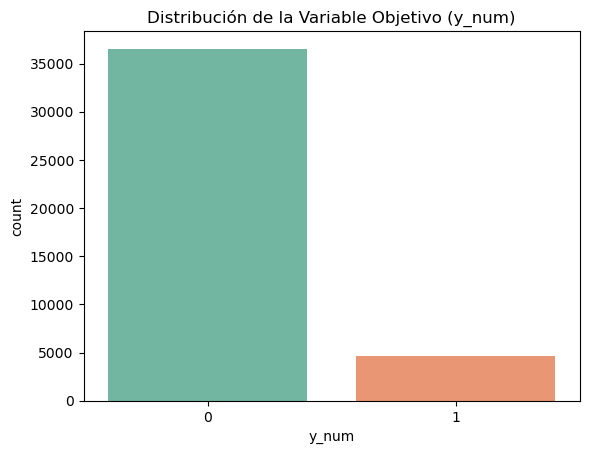

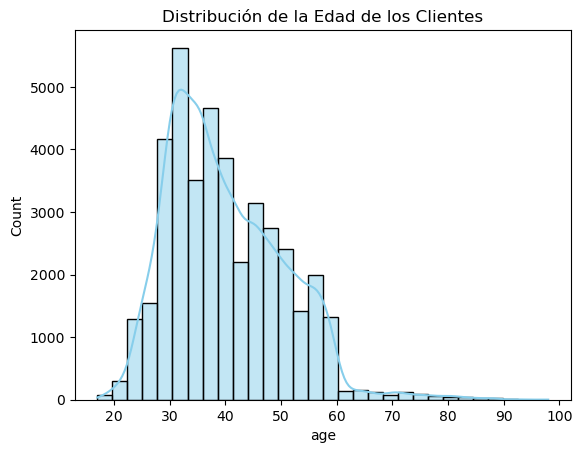

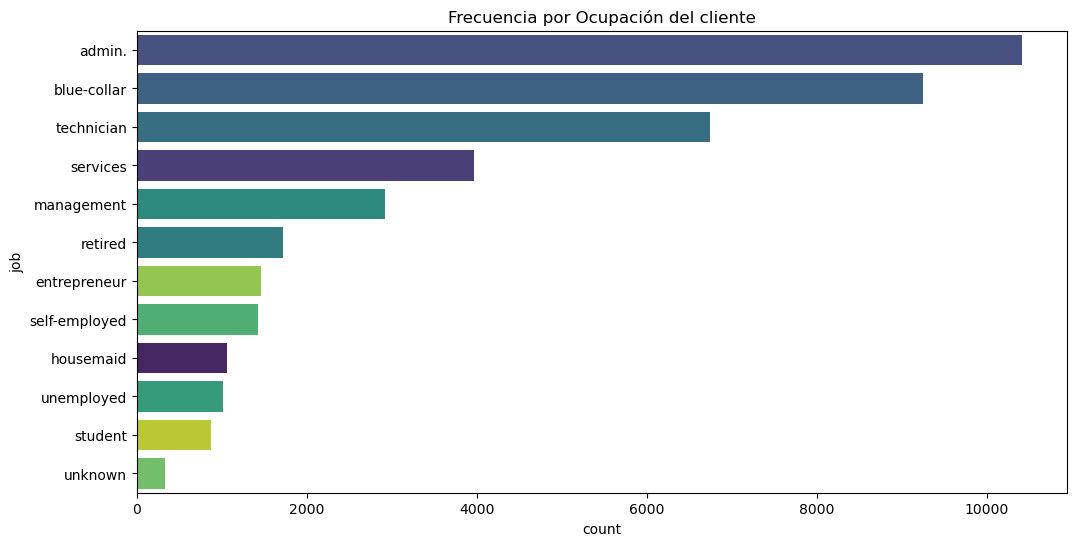

In [170]:

# Distribución de la Variable Objetivo (Target)
_ = plt.figure()
_ = sns.countplot(data=df_n, x='y_num', hue='y_num', palette='Set2', legend=False)
_ = plt.title('Distribución de la Variable Objetivo (y_num)')
_ = plt.show()

# Distribución de la Edad (Numérica)
_ = plt.figure()
_ = sns.histplot(data=df_n, x='age', bins=30, kde=True, color='skyblue')
_ = plt.title('Distribución de la Edad de los Clientes')
_ = plt.show()

# Trabajos más comunes (Categórica)_ = 
_= plt.figure(figsize=(12, 6))
_ = sns.countplot(
    data=df_n, 
    y='job', 
    order=df_n['job'].value_counts().index, 
    palette='viridis', 
    hue='job', 
    legend=False
)
_ = plt.title('Frecuencia por Ocupación del cliente')
_ = plt.show();



Análisis Bivariante

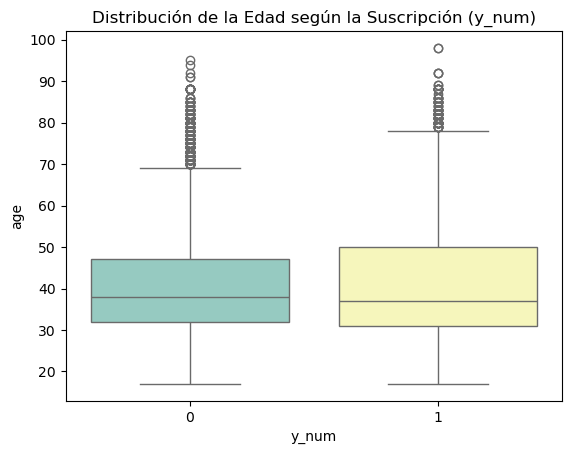

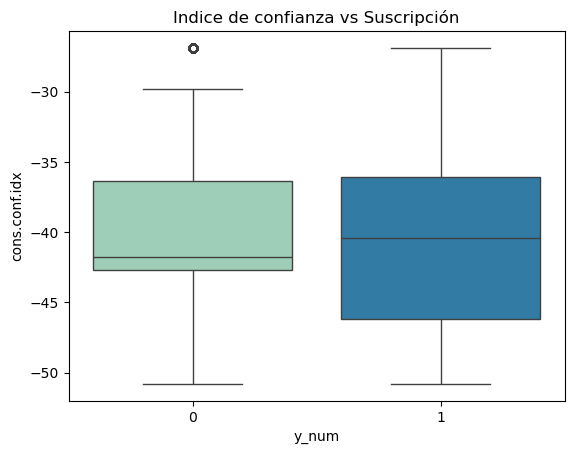

In [171]:
import warnings

warnings.filterwarnings('ignore')

# Edad vs Target (Boxplot)
_ =plt.figure()
_ = sns.boxplot(data=df_n, x='y_num', y='age', hue='y_num', palette='Set3', legend=False)
_ = plt.title('Distribución de la Edad según la Suscripción (y_num)')
_ = plt.show()


# Indice de confianza del cliente vs Target
_ = plt.figure()
_ = sns.boxplot(data=df_n, x='y_num', y='cons.conf.idx', hue='y_num', palette='YlGnBu', legend=False) # Añadido hue y legend
_ = plt.title('Indice de confianza vs Suscripción')
#_ = plt.ylim(0, 10) 
_ = plt.show()

El índice de confianza puede representar una variable importante para este análisis, ya que en los valores positivos muestra una distribución que parece normal con tendencia a cero, que es el máximo nivel de confianza. 

Revision de la variable 'age', debido a los Outliers 

In [172]:
estadistica = df_n['age'].describe()
print(estadistica)

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64


Se emplea este código para determinar el volumen de datos que exceden el umbral de la desviación estándar.

In [173]:
variable = 'age'

# Calculamos la media y la desviación estándar
media = df_n['age'].mean()
desviacion = df_n['age'].std()
limite = media + desviacion

# Contamos cuántos datos superan ese límite
cantidad_atipicos = (df_n['age'] > limite).sum()

# Qué porcentaje del total representan
porcentaje = (cantidad_atipicos / len(df_n)) * 100

# Mostramos resultados limpios
print(f"Media de la variable: {media:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")
print(f"Límite (Media + 1 Desviación): {limite:.2f}\n")
print(f"Datos por encima de este límite: {cantidad_atipicos} ({porcentaje:.2f}% del total)")

Media de la variable: 40.02
Desviación Estándar: 10.42
Límite (Media + 1 Desviación): 50.45

Datos por encima de este límite: 7180 (17.43% del total)


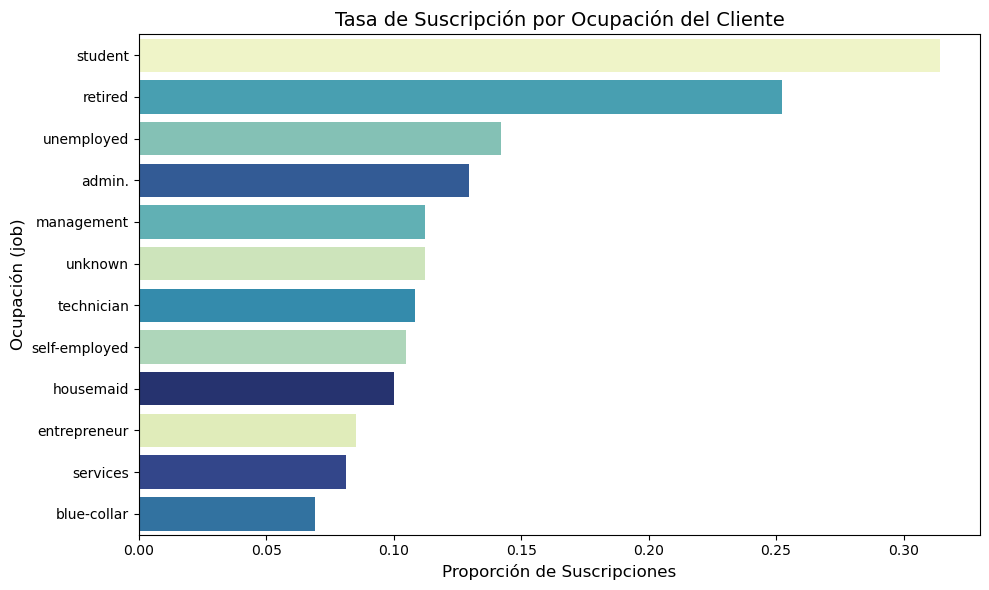

In [174]:
import warnings

warnings.filterwarnings('ignore')

# Calculamos el orden para que el gráfico quede de mayor a menor tasa de éxito
orden_trabajos = df_n.groupby('job')['y_num'].mean().sort_values(ascending=False).index

_ = plt.figure(figsize=(10, 6))
_ = sns.barplot(data=df_n, x='y_num', y='job', order=orden_trabajos, hue='job', palette='YlGnBu_r',legend=False, errorbar=None)

# Ajustes estéticos silenciados
_ = plt.title('Tasa de Suscripción por Ocupación del Cliente', fontsize=14)
_ = plt.xlabel('Proporción de Suscripciones', fontsize=12)
_ = plt.ylabel('Ocupación (job)', fontsize=12)

# Mostrar limpio
_ = plt.tight_layout()
_ = plt.show();

Conclusiones del análisis preliminar de variables

El análisis actual sugiere que la variable duración presenta un sesgo considerable, lo que dificulta su capacidad predictiva. Es lógico que exista una correlación fuerte entre la variable duración y la tasa de conversión porque los clientes que permanecieron más tiempo en la llamada era porque mostraban interés; sin embargo, este parámetro no ayuda en el modelo a predecir resultados debido a que no es posible introducir la duración de la llamada como una variable de entrada para predecir futuras conversiones. 
En contraste, la variable age muestra potencial en su vínculo con la variable objetivo y los outliers de esta variable los tratare categorisando los clientes a partir de un rango de edad. 

### Manipulación de Variables para tratar outliers 

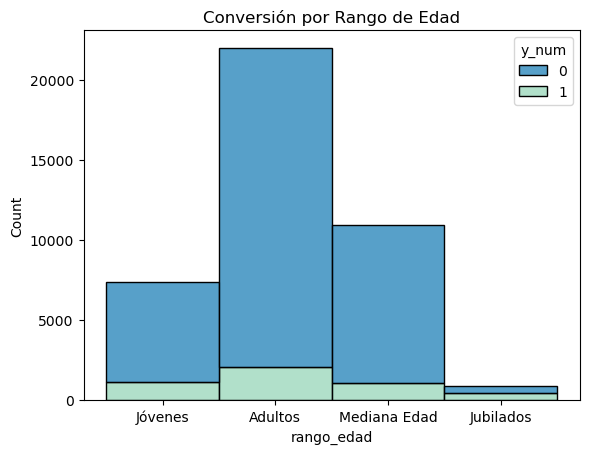

In [175]:
# Crear variable de rangos de edad (Bins)
bins = [16, 30, 45, 60, 100]
labels = ['Jóvenes', 'Adultos', 'Mediana Edad', 'Jubilados']
df_n['rango_edad'] = pd.cut(df_n['age'], bins=bins, labels=labels)

warnings.filterwarnings('ignore')

# Comprobar la conversión por nuevo rango de edad
_=plt.figure()
_=sns.histplot(data=df_n, x='rango_edad', hue='y_num', multiple='stack', palette='YlGnBu_r')
_=plt.title('Conversión por Rango de Edad')
_=plt.show()


In [176]:
df_n.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num,pdays_cat,rango_edad
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Mediana Edad
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Mediana Edad
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Adultos
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Adultos
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Mediana Edad


Despues de una revision de todas las variables voy a eliminar Duration, contact, month, day_of_week. Puden servir de mucho en el diseño de la campaña pero son irrelevantes para la pregunta que quermos responder

In [177]:
columnas_a_eliminar = ['duration','contact','month','day_of_week']
df_n.drop(columns = columnas_a_eliminar, inplace = True)

In [178]:
df_n.head()

,age,job,marital,education,default,housing,loan,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num,pdays_cat,rango_edad
0,56,housemaid,married,basic.4y,no,no,no,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Mediana Edad
1,57,services,married,high.school,unknown,no,no,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Mediana Edad
2,37,services,married,high.school,no,yes,no,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Adultos
3,40,admin.,married,basic.6y,no,no,no,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Adultos
4,56,services,married,high.school,no,no,yes,1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,Mediana Edad


In [179]:
import pandas as pd

# Aplicamos One-Hot Encoding a todas las columnas de texto
df_encoded = pd.get_dummies(df_n, drop_first=True)

# Verificamos el cambio
print(f"Columnas originales: {df_n.shape[1]}")
print(f"Columnas nuevas tras encoding: {df_encoded.shape[1]}")
print("\nPrimeras filas del nuevo dataset:")
display(df_encoded.head())

Columnas originales: 18
Columnas nuevas tras encoding: 42

Primeras filas del nuevo dataset:


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num,pdays_cat,...,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,poutcome_nonexistent,poutcome_success,rango_edad_Adultos,rango_edad_Mediana Edad,rango_edad_Jubilados
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,False,True,False,False,True,False
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,False,True,False,False,True,False
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,True,False,False,True,False,True,False,False
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,False,True,False,True,False,False
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,True,True,False,False,True,False


### IV.- En esta parte del codigo voy a preperar el entrenameinto del modelo 

In [180]:
# Primero definimos X (todas las columnas menos el objetivo) 
# e y (la columna que queremos predecir)
X_gen = df_n.drop(columns=['y_num' , 'age'], errors='ignore')
y_gen = df_n['y_num']


X_encoded_gen = pd.get_dummies(X_gen, drop_first=True, dtype=int)

In [181]:
X_encoded_gen = X_encoded_gen.astype(int)

In [182]:
# Particion train, test 
X_train_gen, X_test_gen, y_train_gen, y_test_gen = train_test_split(
    X_encoded_gen, 
    y_gen, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_gen
)

# Verificación de que todo salió bien
print(f"Columnas en el modelo: {X_encoded_gen.shape[1]}")
print(f"Ejemplos para entrenar: {X_train_gen.shape[0]}")
print(f"Ejemplos para probar: {X_test_gen.shape[0]}")

Columnas en el modelo: 40
Ejemplos para entrenar: 32950
Ejemplos para probar: 8238


### V.- Primer modelo de regresión logística

Verdaderos Negativos (TN): 7228
Falsos Positivos (FP): 82
Falsos Negativos (FN): 750
Verdaderos Positivos (TP): 178
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.68      0.19      0.30       928

    accuracy                           0.90      8238
   macro avg       0.80      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238



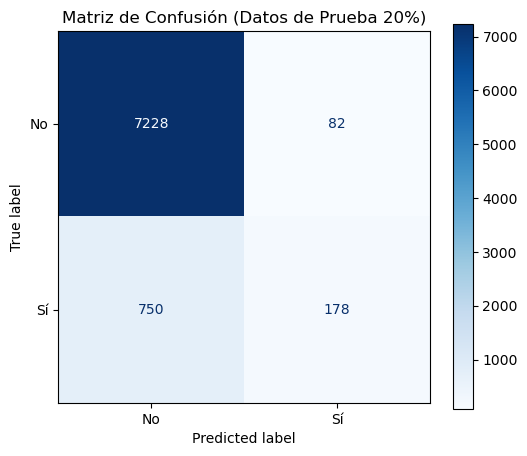

In [183]:
# Definir y entrenar el modelo de Regresión Logística
modelo = LogisticRegression(max_iter=5000, random_state=42)

# ENTRENAMOS SOLO CON EL 80% DE LOS DATOS (Train)
modelo.fit(X_train_gen, y_train_gen)

# Predecir utilizando SOLO EL 20% DE PRUEBA (Test)
y_pred = modelo.predict(X_test_gen)

# Generar la Matriz de Confusión evaluando las predicciones contra la realidad del test
cm = confusion_matrix(y_test_gen, y_pred)

# Imprimir los resultados exactos
print(f"Verdaderos Negativos (TN): {cm[0][0]}")
print(f"Falsos Positivos (FP): {cm[0][1]}")
print(f"Falsos Negativos (FN): {cm[1][0]}")
print(f"Verdaderos Positivos (TP): {cm[1][1]}")

# Usamos y_test para el reporte
print(classification_report(y_test_gen, y_pred))

# Guardar el gráfico de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
_ = plt.title("Matriz de Confusión (Datos de Prueba 20%)")
_ = plt.savefig('confusion_matrix_test.png', bbox_inches='tight')
_ = plt.show();

La matriz de confusión revela un desequilibrio importante en la capacidad predictiva. El modelo muestra un alto desempeño en la identificación de clientes sin intención de compra, pero falla significativamente al detectar la clase positiva, con un volumen de 750 omisiones frente a solo 178 detecciones exitosas.

Debido al desbalance en el dataset, la primera opción será un balanceo de clases.

### VI.- Modelo de regresión logística con balanceo de clases  

Verdaderos Negativos (TN): 5852
Falsos Positivos (FP): 1458
Falsos Negativos (FN): 281
Verdaderos Positivos (TP): 647
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      7310
           1       0.31      0.70      0.43       928

    accuracy                           0.79      8238
   macro avg       0.63      0.75      0.65      8238
weighted avg       0.88      0.79      0.82      8238



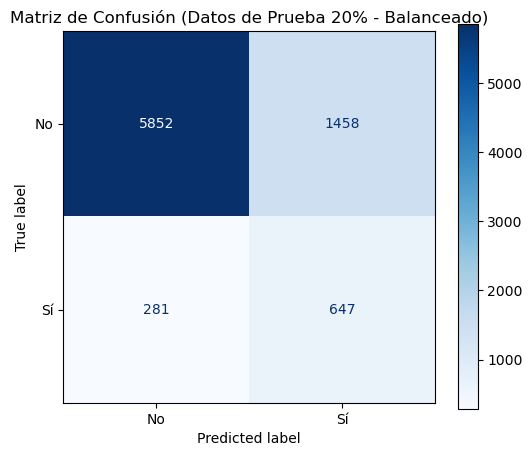

In [184]:
# Definir y entrenar el modelo de Regresión Logística con BALANCEO DE CLASES
modelo = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')

modelo.fit(X_train_gen, y_train_gen)

y_pred = modelo.predict(X_test_gen)

# Generar la Matriz de Confusión 
cm = confusion_matrix(y_test_gen, y_pred)


print(f"Verdaderos Negativos (TN): {cm[0][0]}")
print(f"Falsos Positivos (FP): {cm[0][1]}")
print(f"Falsos Negativos (FN): {cm[1][0]}")
print(f"Verdaderos Positivos (TP): {cm[1][1]}")


print(classification_report(y_test_gen, y_pred))


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
_ = plt.title("Matriz de Confusión (Datos de Prueba 20% - Balanceado)")
_ = plt.savefig('confusion_matrix_test.png', bbox_inches='tight')
_ = plt.show();

El empleo de una regresión logística con balanceo de clases constituye una respuesta efectiva al marcado desequilibrio del conjunto de datos. Esta aproximación mitiga el sesgo generado por la disparidad entre la amplia mayoría de clientes que no realizan la compra y el grupo minoritario que sí adquiere los productos bancarios.

## Ejemplo de prueba basado en costos asociados  

### Supuesto 

#### Costo de realizar la llamada (Falso Positivo)

Este es el costo de contactar a una persona que no realizará la compra. Se calcula sumando el sueldo del agente, la tecnología del centro de llamadas y los costos operativos.

Costo estimado: 1.50 - 3.50 USD (o 1.40 - 3.20 €) por llamada intentada.
¿Qué incluye?

Salario o comisión: El tiempo del agente (entre 3 y 5 minutos entre marcado y conversación).

Infraestructura: Software de CRM, telefonía IP y servicios en la nube.

Costo de oportunidad: El tiempo en el que el agente no está llamando a alguien con disposición de compra.

#### Costo de perder a un cliente interesado (Falso Negativo)

Este es el beneficio que la entidad deja de percibir debido a que el modelo determina no realizar la llamada y el cliente estaba dispuesto a contratar. En el sector bancario, esto se mide a través del margen de interés y el LTV (valor de vida del cliente).

Beneficio estimado por depósito: 150 - 400 USD (o 135 - 370 €).
¿De dónde proviene ese capital?

Margen de intermediación: Si el cliente deposita 10,000 y el banco presta ese dinero a una tasa mayor, la ganancia neta anual suele situarse entre el 2 por ciento y el 3 por ciento.

Venta cruzada: Un cliente con un depósito presenta una mayor propensión a adquirir una tarjeta de crédito o un seguro, lo que incrementa su valor a largo plazo

#### Ejemplo de negocios 

Bajo un supuesto de ganancia de 200 USD por cada nuevo contrato y un costo unitario por llamada de 2.50 USD, el punto de equilibrio se alcanza en los 80 contactos. (200/2.5)=80

#### Prueba de ajuste del umbral

Basándose en el supuesto del apartado anterior, se llevará a cabo un ajuste del umbral de decisión para maximizar la captación de clientes y evaluar su impacto en el presupuesto de la campaña.

RESULTADOS CON UMBRAL 0.3
[[3242 4068]
 [ 148  780]]
              precision    recall  f1-score   support

           0       0.96      0.44      0.61      7310
           1       0.16      0.84      0.27       928

    accuracy                           0.49      8238
   macro avg       0.56      0.64      0.44      8238
weighted avg       0.87      0.49      0.57      8238



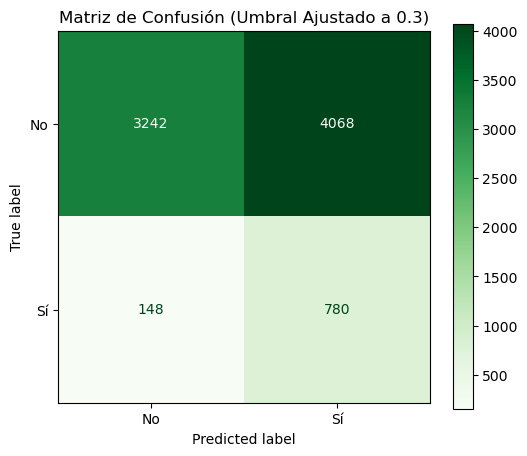

In [185]:
from sklearn.metrics import confusion_matrix, classification_report

y_probs = modelo.predict_proba(X_test_gen)[:, 1] 

# Probamos con un umbral más "ambicioso" (0.3) para captar más ventas
umbral = 0.3
y_pred_ajustado = (y_probs >= umbral).astype(int)


print(f"RESULTADOS CON UMBRAL {umbral}")
print(confusion_matrix(y_test_gen, y_pred_ajustado))
print(classification_report(y_test_gen, y_pred_ajustado))

cm_ajustada = confusion_matrix(y_test_gen, y_pred_ajustado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ajustada, display_labels=['No', 'Sí'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens') 
plt.title(f"Matriz de Confusión (Umbral Ajustado a {umbral})")
plt.show();



En este ejemplo, cada conversión exitosa (verdadero positivo) genera un beneficio estimado de 200 USD. El umbral de rentabilidad se sitúa en un máximo de 80 contactos fallidos por cada acierto, considerando un costo operativo aproximado por llamada de 2.50 USD.
Por lo tanto, el modelo resulta rentable mientras el cociente entre falsos positivos y verdaderos positivos sea inferior a 80. en el caso de un umbral de 0.3 este cociente es de 5.3 lo que hace que esta sea una solucion viable 

Evaluación de pesos del modelo 

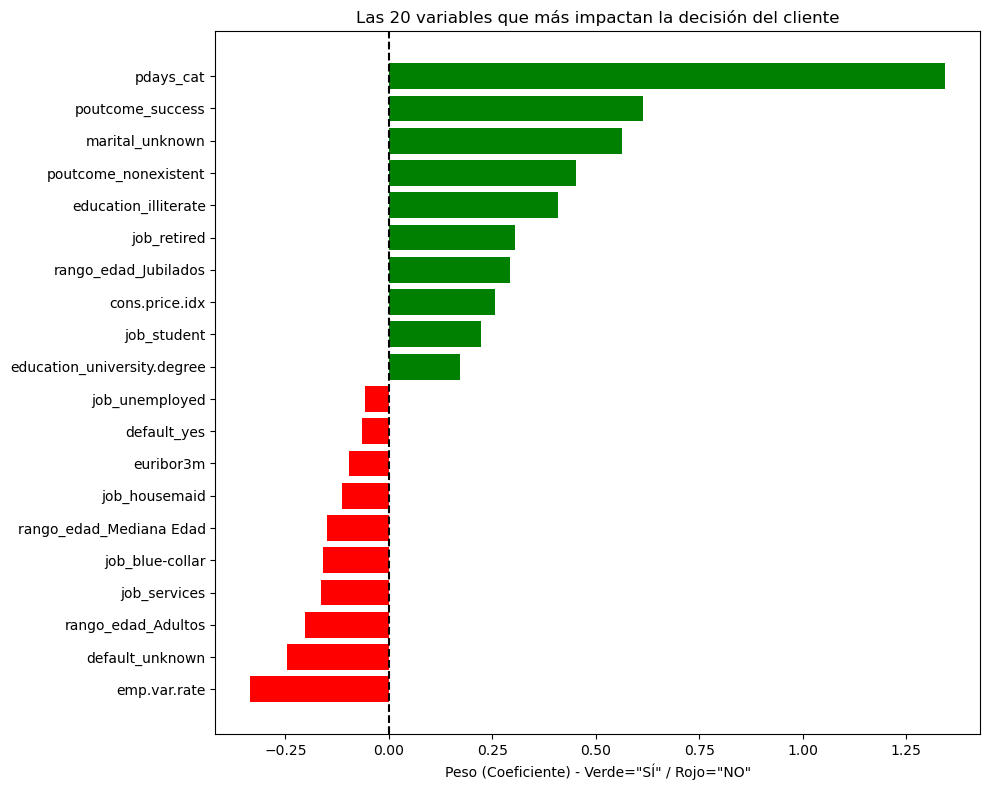

In [186]:
# Extraemos los nombres de las columnas y los pesos (coeficientes) del modelo
nombres_variables = X_train_gen.columns
coeficientes = modelo.coef_[0]

# Creamos una tabla (DataFrame) para organizarlos
importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes
})

# Ordenamos de mayor a menor importancia
importancia = importancia.sort_values(by='Coeficiente', ascending=False)

# Seleccionamos el Top 10 que más impulsan el "Sí" y el Top 10 que más impulsan el "No"
top_positivas = importancia.head(10)
top_negativas = importancia.tail(10)
top_total = pd.concat([top_positivas, top_negativas]).sort_values(by='Coeficiente')

# Graficamos los resultados
plt.figure(figsize=(10, 8))
colores = ['red' if x < 0 else 'green' for x in top_total['Coeficiente']]

plt.barh(top_total['Variable'], top_total['Coeficiente'], color=colores)
plt.title('Las 20 variables que más impactan la decisión del cliente')
plt.xlabel('Peso (Coeficiente) - Verde="SÍ" / Rojo="NO"')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show();

#### Revisión interna de la variables del modelo 

La relevancia de pdays_cat y poutcome_success en el análisis de importancia de variables demuestra que el histórico de interacción con el cliente es un factor decisivo. En consecuencia, el fortalecimiento de las estrategias de seguimiento se presenta como una prioridad para elevar la tasa de conversión.

In [187]:
display(df_encoded.head())

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num,pdays_cat,...,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,poutcome_nonexistent,poutcome_success,rango_edad_Adultos,rango_edad_Mediana Edad,rango_edad_Jubilados
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,False,True,False,False,True,False
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,False,True,False,False,True,False
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,True,False,False,True,False,True,False,False
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,False,True,False,True,False,False
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,...,False,False,False,False,True,True,False,False,True,False


#### Dentro del Data set existen variables como 

emp.var.rate	Tasa de variación del empleo - indicador trimestral (numérico).

cons.price.idx	Índice de precios al consumidor - indicador mensual (numérico).

cons.conf.idx	Índice de confianza del consumidor - indicador mensual (numérico).

euribor3m	Tasa Euribor a 3 meses - indicador diario (numérico).

nr.employed	Número de empleados - indicador trimestral (numérico)

El conjunto de datos integra indicadores macroeconómicos como la tasa de variación del empleo y el índice de precios al consumidor. Inicialmente se atribuyó una relevancia alta a estos factores; no obstante, su escala y magnitud podrían interferir en la convergencia del algoritmo. Por este motivo, se llevará a cabo una evaluación de su importancia relativa para determinar si requieren un proceso de normalización o estandarización.

In [188]:
peso_confianza = importancia[importancia['Variable'] == 'cons.conf.idx']
print(peso_confianza)

        Variable  Coeficiente
4  cons.conf.idx     0.009145


Con base en este factor de importancia, se aplicarán técnicas de transformación de escala para verificar si la inclusión de indicadores macroeconómicos incrementa la precisión de las predicciones.

### VII.- Análisis de validación del modelo de regresión logística con normalización de los predictores.

In [189]:
# Primero definimos X_nor e y_nor
X_nor = df_n.drop(columns=['y_num' , 'age'], errors='ignore')
y_nor = df_n['y_num']

X_encoded_nor = pd.get_dummies(X_gen, drop_first=True, dtype=int)
X_encoded_nor = X_encoded_nor.astype(int)

# Particion train, test (Añadimos _gen a todo)
X_train_nor, X_test_nor, y_train_nor, y_test_nor = train_test_split(
    X_encoded_nor, 
    y_gen, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_gen
)

Resultados con Datos Escalados
[[5886 1424]
 [ 285  643]]
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      7310
           1       0.31      0.69      0.43       928

    accuracy                           0.79      8238
   macro avg       0.63      0.75      0.65      8238
weighted avg       0.88      0.79      0.82      8238



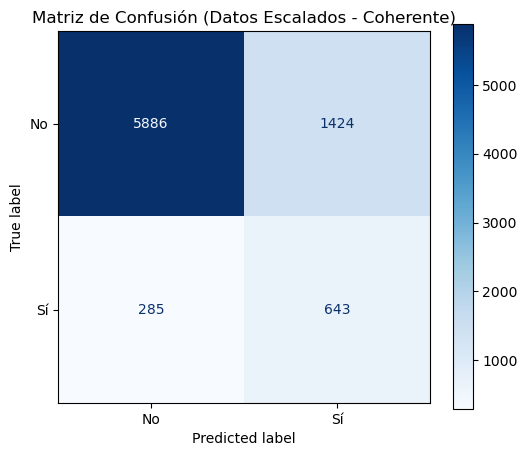

In [190]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix



# Escalador
scaler = StandardScaler()

# Escalamos los datos de Entrenamiento 
X_train_scaled = scaler.fit_transform(X_train_nor)

# Escalamos los datos de Prueba 
X_test_scaled = scaler.transform(X_test_nor)

# Re-entrenamos el modelo con los datos balanceados y AHORA ESCALADOS
modelo_escalado = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
modelo_escalado.fit(X_train_scaled, y_train_nor)


y_pred_scaled = modelo_escalado.predict(X_test_scaled)

# Matriz de confusion 
cm_escalada = confusion_matrix(y_test_nor, y_pred_scaled)

print("Resultados con Datos Escalados")
print(cm_escalada)
print(classification_report(y_test_nor, y_pred_scaled))

# Graficamos usando la variable: cm_escalada

disp = ConfusionMatrixDisplay(confusion_matrix=cm_escalada, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')

plt.title("Matriz de Confusión (Datos Escalados - Coherente)")
plt.savefig('confusion_matrix_escalada.png', bbox_inches='tight')
plt.show();

El escalamiento de las variables no mejora las predicciones del modelo 

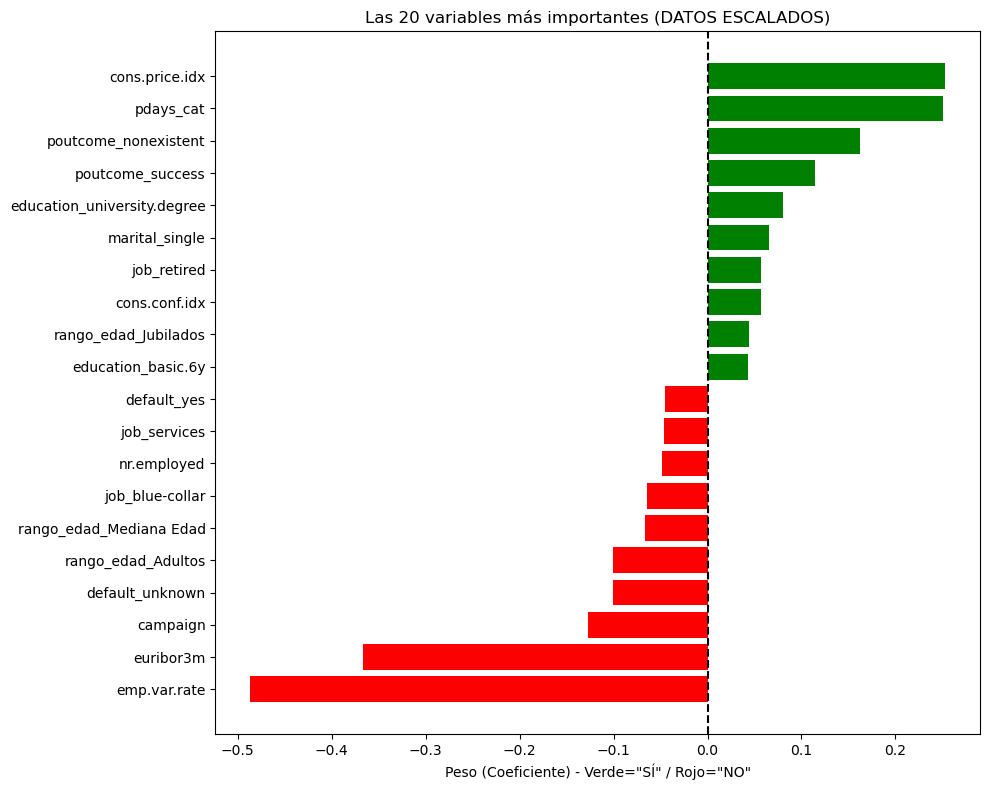

In [191]:
# Una vez mas revisaremos lo pesos de las variables consideradas en el modelo 
nombres_variables = X_train_nor.columns
coeficientes_escalados = modelo_escalado.coef_[0] 

# Creamos la tabla combinando los nombres con los nuevos pesos
importancia_esc = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes_escalados
})

# Ordenamos de mayor a menor
importancia_esc = importancia_esc.sort_values(by='Coeficiente', ascending=False)

# Seleccionamos el Top 10 positivo y negativo
top_positivas = importancia_esc.head(10)
top_negativas = importancia_esc.tail(10)
top_total = pd.concat([top_positivas, top_negativas]).sort_values(by='Coeficiente')

# Graficamos

plt.figure(figsize=(10, 8))
colores = ['red' if x < 0 else 'green' for x in top_total['Coeficiente']]

plt.barh(top_total['Variable'], top_total['Coeficiente'], color=colores)
plt.title('Las 20 variables más importantes (DATOS ESCALADOS)')
plt.xlabel('Peso (Coeficiente) - Verde="SÍ" / Rojo="NO"')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show();

La representación de los coeficientes del modelo confirma la integración de variables macroeconómicas y su relevancia como criterios determinantes en la clasificación.

Relevancia del índice de confianza del consumidor como predictor del comportamiento financiero

In [192]:
peso_confianza = importancia[importancia_esc['Variable'] == 'cons.conf.idx']
print(peso_confianza)

        Variable  Coeficiente
4  cons.conf.idx     0.009145


Revisión del peso comparativo de la variable pdays_cat en ambos modelos 

In [193]:
print("Antes:", importancia[importancia['Variable'] == 'pdays_cat']['Coeficiente'].values)
print("Después:", importancia_esc[importancia_esc['Variable'] == 'pdays_cat']['Coeficiente'].values)

Antes: [1.34419079]
Después: [0.25076192]


A pesar de la redistribución en la importancia de los predictores, la aplicación de un escalado global no ha generado un incremento significativo en el rendimiento del modelo.

Para concluir esta fase de análisis, se procederá con un escalamiento selectivo de las variables identificadas como críticas para el modelo.

[[5882 1428]
 [ 285  643]]
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      7310
           1       0.31      0.69      0.43       928

    accuracy                           0.79      8238
   macro avg       0.63      0.75      0.65      8238
weighted avg       0.88      0.79      0.82      8238



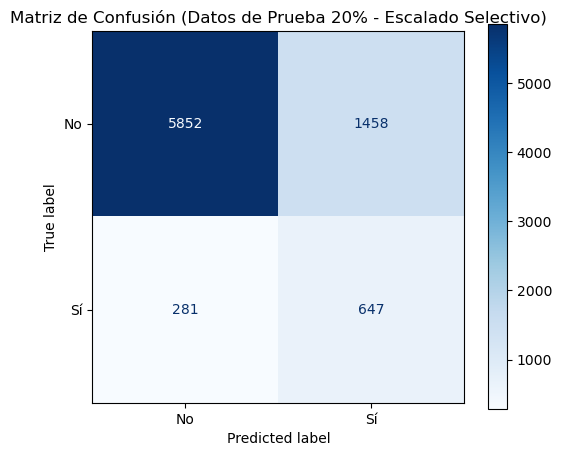

In [194]:
# Identificamos solo las columnas que son números  (no dummies)
cols_numericas = ['campaign', 'previous', 'emp.var.rate', 
                  'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Creamos una copia de tus datos para no dañar los originales
X_train_opt = X_train_nor.copy()
X_test_opt = X_test_nor.copy()

# Escalamos SOLO esas columnas
scaler = StandardScaler()
X_train_opt[cols_numericas] = scaler.fit_transform(X_train_nor[cols_numericas])
X_test_opt[cols_numericas] = scaler.transform(X_test_nor[cols_numericas])

# Entrenamos el modelo con estos datos "híbridos"
modelo_opt = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
modelo_opt.fit(X_train_opt, y_train_nor)

# Evaluamos
y_pred_opt = modelo_opt.predict(X_test_opt)
print(confusion_matrix(y_test_nor, y_pred_opt))
print(classification_report(y_test_nor, y_pred_opt))

# Graficamos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
_ = plt.title("Matriz de Confusión (Datos de Prueba 20% - Escalado Selectivo)")
_ = plt.savefig('confusion_matrix_test.png', bbox_inches='tight')
_ = plt.show();

En conclusión, la implementación de esta estrategia no ha logrado superar el rendimiento obtenido mediante el balanceo de clases y el ajuste del umbral de decisión.

### VIII Optimización del modelo 

Partiendo del modelo de mejor predicción, haremos una optimización de manera de intentar incrementar el porcentaje de predicciones positivas.

Mejor parámetro 'C' encontrado: 0.001

REPORTE DETALLADO (MODELO OPTIMIZADO)
              precision    recall  f1-score   support

           0       0.96      0.75      0.84      7310
           1       0.27      0.73      0.40       928

    accuracy                           0.75      8238
   macro avg       0.61      0.74      0.62      8238
weighted avg       0.88      0.75      0.79      8238



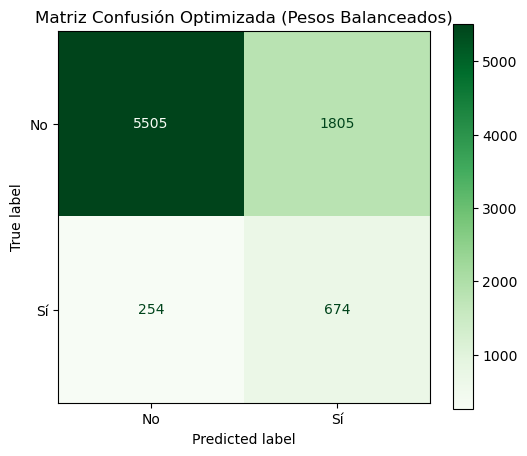

In [195]:
# OPTIMIZACIÓN Pesos Balanceados y Búsqueda de Hiperparámetros
modelo_base = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

# Buscamos el mejor nivel de regularización priorizando atrapar clientes (scoring='recall')
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(modelo_base, param_grid, cv=5, scoring='recall')
grid.fit(X_train_opt, y_train_nor)

# Nos quedamos con el mejor modelo
best_model = grid.best_estimator_

# Evaluamos los resultados con los datos de prueba
y_pred_op = best_model.predict(X_test_opt)
cm = confusion_matrix(y_test_nor, y_pred_op)

print(f"Mejor parámetro 'C' encontrado: {grid.best_params_['C']}\n")
print("REPORTE DETALLADO (MODELO OPTIMIZADO)")
print(classification_report(y_test_nor, y_pred_op))

# Generar la nueva matriz 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens')
plt.title("Matriz Confusión Optimizada (Pesos Balanceados)")
plt.savefig('matriz_optimizada.png', bbox_inches='tight')
plt.show();

El comportamiento optimizado mejora en relación con el modelo balanceado, pero no con respecto al modelo con el umbral más agresivo.

En el siguiente paso usaremos el mismo umbralde 0.2 para ver el comportamiento del modelo predictivo 

Mejor parámetro 'C' encontrado: 0.001
Umbral de decisión aplicado: 0.2

REPORTE DETALLADO (MODELO OPTIMIZADO + UMBRAL)
              precision    recall  f1-score   support

           0       0.94      0.01      0.03      7310
           1       0.11      0.99      0.20       928

    accuracy                           0.13      8238
   macro avg       0.53      0.50      0.12      8238
weighted avg       0.85      0.13      0.05      8238



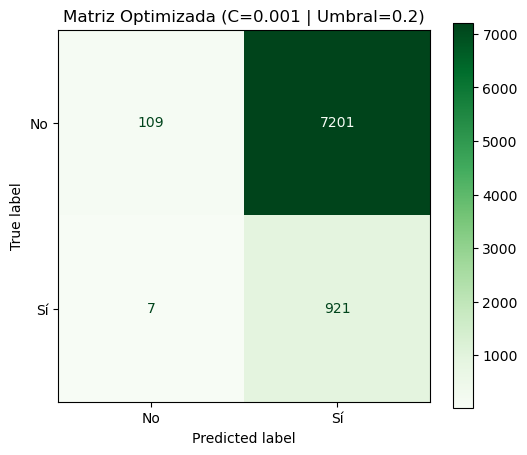

In [196]:
# MEJOR MODELO 
y_probs = best_model.predict_proba(X_test_opt)[:, 1]

# Definimos nuestro umbral 
umbral_personalizado = 0.2
y_pred_umbral = (y_probs >= umbral_personalizado).astype(int)

# Calculamos la matriz con el nuevo umbral
cm_umbral = confusion_matrix(y_test_nor, y_pred_umbral)

print(f"Mejor parámetro 'C' encontrado: {grid.best_params_['C']}")
print(f"Umbral de decisión aplicado: {umbral_personalizado}\n")
print("REPORTE DETALLADO (MODELO OPTIMIZADO + UMBRAL)")
print(classification_report(y_test_nor, y_pred_umbral))

# Generar la matriz visual con los datos del umbral
disp = ConfusionMatrixDisplay(confusion_matrix=cm_umbral, display_labels=['No', 'Sí'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens')
plt.title(f"Matriz Optimizada (C={grid.best_params_['C']} | Umbral={umbral_personalizado})")
plt.show();

Tomando el modelo con el balanceo de clases y un umbral de 0,2 se logra un muy buen nivel de predicción.

In [197]:
# CALCULO DE BENEFICIO CON EL EJEMPLO DEL SUPUESTO 
support_total_no = 7310
support_total_si = 928
recall_si = 0.99
recall_no = 0.01

# Calculamos la matriz de confusión exacta
tp_g = int(support_total_si * recall_si)  # Ventas conseguidas
tn_g = int(support_total_no * recall_no)  # Aciertos en el 'No'
fp_g = support_total_no - tn_g           # Llamadas desperdiciadas (Falsos Positivos)

# PARÁMETROS FINANCIEROS
costo_llamada = 2.50
beneficio_venta = 200.00

# CÁLCULOS DE RENTABILIDAD (Ejemplo)
gasto_operativo = fp_g * costo_llamada
ingreso_bruto = tp_g * beneficio_venta
beneficio_neto = ingreso_bruto - gasto_operativo
eficiencia_llamada = (tp_g / (tp_g + fp_g)) * 100

print(f"ANALISIS DEL EJEMPLO HIPOTETICO: MODELO OPTIMIZADO CON UMBRAL DE 0.3")
print(f"Mejor C: 0.001 | Umbral: 0.3")
print("-" * 45)
print(f"Ventas capturadas (TP): {tp_g} de {support_total_si}")
print(f"Llamadas fallidas (FP): {fp_g}")
print(f"Inversión en llamadas perdidas: ${gasto_operativo:,.2f} USD")
print(f"Ingresos por ventas: ${ingreso_bruto:,.2f} USD")
print(f"BENEFICIO NETO TOTAL: ${beneficio_neto:,.2f} USD")
print(f"EFICIENCIA: {eficiencia_llamada:.2f}% (1 éxito cada {int(100/eficiencia_llamada)} llamadas)")

ANALISIS DEL EJEMPLO HIPOTETICO: MODELO OPTIMIZADO CON UMBRAL DE 0.3
Mejor C: 0.001 | Umbral: 0.3
---------------------------------------------
Ventas capturadas (TP): 918 de 928
Llamadas fallidas (FP): 7237
Inversión en llamadas perdidas: $18,092.50 USD
Ingresos por ventas: $183,600.00 USD
BENEFICIO NETO TOTAL: $165,507.50 USD
EFICIENCIA: 11.26% (1 éxito cada 8 llamadas)


Bajo el supuesto de un costo operativo de 2.50 USD y un beneficio por conversión de 250 USD, el modelo alcanza un factor de retorno de 7.8. Esta métrica lo posiciona como la alternativa más eficiente para la identificación de compradores potenciales dentro del portafolio bancario.

## ------ ESTRATEGIA ALTERNATIVA ------

### IX.- Estrategia de segmentación del Dataset
Esta fase del estudio se centra en la categorización de los clientes mediante un análisis de propensity scoring. Al estratificar la base de datos en niveles de probabilidad, se facilita la identificación de los perfiles con mayor potencial de respuesta a la campaña.

In [198]:
from sklearn.cluster import KMeans
import pandas as pd

# Seleccionamos variables numéricas clave para segmentar
X_clustering = df[['age', 'euribor3m', 'campaign', 'pdays_cat', 'cons.conf.idx']]

# Escalar para K-Means
scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_clustering)

# Creamos 4 segmentos (Perfiles de Clientes)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segmento'] = kmeans.fit_predict(X_km_scaled)

# Revision de la tasa de conversion por segmento 
analisis = df.groupby('segmento')['y_num'].mean().sort_values(ascending=False)
print("TASA DE CONVERSIÓN POR SEGMENTO ")
print(analisis)

TASA DE CONVERSIÓN POR SEGMENTO 
segmento
2    0.638284
3    0.167295
0    0.069213
1    0.040749
Name: y_num, dtype: float64


In [199]:
segmentos_buenos = analisis.index[:2] # Tomamos los 2 mejores segmentos
df_premium = df[df['segmento'].isin(segmentos_buenos)].copy()

print(f"Clientes originales: {len(df_n)}")
print(f"Clientes tras el filtro de calidad: {len(df_premium)}")

Clientes originales: 41188
Clientes tras el filtro de calidad: 11587


In [200]:
# CREAMOS EL NUEVO DATASET
df_segmentado = df.copy()

# ASEGURAMOS LAS ETIQUETAS
df_segmentado['segmento'] = kmeans.labels_

# MAPEAMOS LOS NOMBRES 
nombres_map = {
    0: 'Cartera General (Volumen)', 
    1: 'Fricción Comercial (Saturados)', 
    2: 'Jubilados Estables / Plazo Fijo', 
    3: 'Alto Riesgo / No Objetivo'
}

df_segmentado['nombre_segmento'] = df_segmentado['segmento'].map(nombres_map)

# VERIFICACIÓN 
print("RESUMEN DEL NUEVO DATASET SEGMENTADO")
print(f"Total de registros: {len(df_segmentado)}")
print("\nConteo por cada perfil creado:")
print(df_segmentado['nombre_segmento'].value_counts())



RESUMEN DEL NUEVO DATASET SEGMENTADO
Total de registros: 41188

Conteo por cada perfil creado:
nombre_segmento
Cartera General (Volumen)          27466
Alto Riesgo / No Objetivo          10072
Fricción Comercial (Saturados)      2135
Jubilados Estables / Plazo Fijo     1515
Name: count, dtype: int64


Usando K-means, he segmentado el data set y he creado otro data set segmentado 

Grafico para ver la segmentación 

In [201]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Datos ESCALADOS 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_km_scaled)

# DataFrame para graficar
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['segmento'] = df['segmento'] 

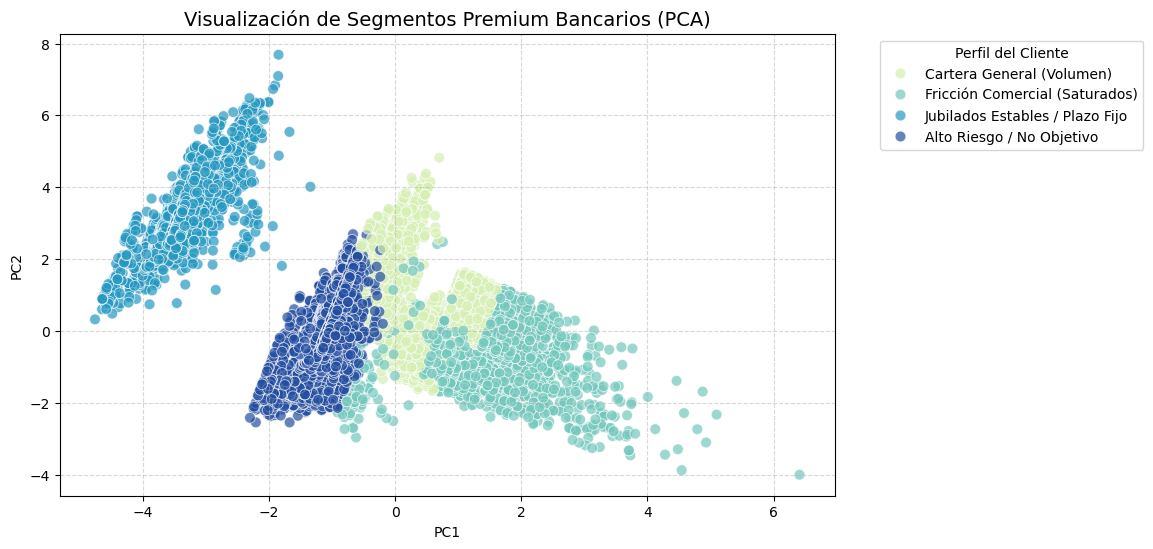

In [202]:
# Mapeamos los números a nombres de negocio reales

nombres_map = {
    0: 'Cartera General (Volumen)',        # Tasa de éxito media/baja, volumen alto
    1: 'Fricción Comercial (Saturados)',    # Contactados muchas veces, tasa bajísima
    2: 'Jubilados Estables / Plazo Fijo',   # Edad alta, éxito alto, economía estable
    3: 'Alto Riesgo / No Objetivo'           # Bajísima tasa, perfil económico inestable
}

# Nueva columna en el DataFrame de PCA
df_pca['nombre_segmento'] = df_pca['segmento'].map(nombres_map)

# Graficamos la matriz segmentada 
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='nombre_segmento', 
                data=df_pca, palette='YlGnBu', alpha=0.7, s=60)

plt.title("Visualización de Segmentos Premium Bancarios (PCA)", fontsize=14)
plt.legend(title='Perfil del Cliente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)


plt.savefig('mapa_segmentos_marketing.png', bbox_inches='tight')
plt.show();

In [203]:
# Nombres de los grupos que queremos rescatar
segmentos_vip = [
    'Jubilados Estables / Plazo Fijo', 
    'Cartera General (Volumen)'
]

# Filtramos el dataset segmentado para crear el Dataset de Alto Valor
df_top_marketing = df_segmentado[df_segmentado['nombre_segmento'].isin(segmentos_vip)].copy()

# Revisión despues de la segmentacion y eliminación de los alto riesgo y de alta fricción 
eliminados = len(df_segmentado) - len(df_top_marketing)
print(f"REPORTE DE FILTRADO")
print(f"Clientes totales iniciales: {len(df_segmentado)}")
print(f"Clientes descartados (Riesgo/Fricción): {eliminados}")
print(f"Clientes en el nuevo dataset 'df_top_marketing': {len(df_top_marketing)}")

# Comprobación 
tasa_original = (df_segmentado['y_num'].mean() * 100)
tasa_nueva = (df_top_marketing['y_num'].mean() * 100)

print(f"\nPROBABILIDAD DE VENTA ANTES: {tasa_original:.2f}%")
print(f"PROBABILIDAD DE VENTA AHORA: {tasa_nueva:.2f}%")

REPORTE DE FILTRADO
Clientes totales iniciales: 41188
Clientes descartados (Riesgo/Fricción): 12207
Clientes en el nuevo dataset 'df_top_marketing': 28981

PROBABILIDAD DE VENTA ANTES: 11.27%
PROBABILIDAD DE VENTA AHORA: 9.90%


Descartando los segmentos alto riesgo y Alta fricción disminuye la probabilidad de venta 

In [204]:
# Miramos la tasa de éxito REAL por cada nombre de segmento
analisis_real = df_segmentado.groupby('nombre_segmento')['y_num'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

# Añadimos la media global para comparar
media_global = df_segmentado['y_num'].mean()

print(f"DIAGNÓSTICO DE SEGMENTOS (Media Global: {media_global:.4f})")
print(analisis_real)

DIAGNÓSTICO DE SEGMENTOS (Media Global: 0.1127)
                                     mean  count
nombre_segmento                                 
Jubilados Estables / Plazo Fijo  0.638284   1515
Alto Riesgo / No Objetivo        0.167295  10072
Cartera General (Volumen)        0.069213  27466
Fricción Comercial (Saturados)   0.040749   2135


Prueba de probabilidad de conversión dejando el grupo de alto riesgo y descartando la cartera general debido a su alta tasa de conversión de 0.16

In [205]:
#  Definimos los segmentos que VAMOS A ELIMINAR
segmentos_a_quitar = [
    'Fricción Comercial (Saturados)', 
    'Cartera General (Volumen)'
]

# Creamos el dataset filtrado (df_top_marketing)
df_top_marketing = df_segmentado[~df_segmentado['nombre_segmento'].isin(segmentos_a_quitar)].copy()

# Verificamos el impacto real en la probabilidad
tasa_original = df_segmentado['y_num'].mean() * 100
tasa_nueva = df_top_marketing['y_num'].mean() * 100

print(f"FILTRADO ESTRATÉGICO FINAL")
print(f"Segmentos conservados: {df_top_marketing['nombre_segmento'].unique().tolist()}")
print(f"Clientes restantes: {len(df_top_marketing)} de {len(df_segmentado)}")
print(f"\nProbabilidad de venta ORIGINAL: {tasa_original:.2f}%")
print(f"Probabilidad de venta ACTUALIZADA: {tasa_nueva:.2f}%")

if tasa_nueva > tasa_original:
    print(f"Potencial de venta {((tasa_nueva/tasa_original)-1)*100:.1f}%")

FILTRADO ESTRATÉGICO FINAL
Segmentos conservados: ['Jubilados Estables / Plazo Fijo', 'Alto Riesgo / No Objetivo']
Clientes restantes: 11587 de 41188

Probabilidad de venta ORIGINAL: 11.27%
Probabilidad de venta ACTUALIZADA: 22.89%
Potencial de venta 103.2%


Ahora intento rescatar del segmento de Cartera General los clientes con mejor probabilidad de conversión usando K means nuevamente 

In [206]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Filtramos solo la Cartera General del dataset segmentado
df_cartera = df_segmentado[df_segmentado['nombre_segmento'] == 'Cartera General (Volumen)'].copy()

# Seleccionamos las variables numéricas (las mismas de antes)
vars_segmentacion = ['age', 'euribor3m', 'campaign', 'pdays_cat', 'cons.conf.idx']
X_sub = df_cartera[vars_segmentacion]


# Hay que escalar de nuevo porque los rangos dentro de este grupo son distintos al total
scaler_sub = StandardScaler()
X_sub_scaled = scaler_sub.fit_transform(X_sub)

In [207]:
# Aplicamos K-Means (3 clusters para micro-segmentar)
kmeans_sub = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cartera['sub_segmento'] = kmeans_sub.fit_predict(X_sub_scaled)

# ANALIZAMOS ESTOS SUB-GRUPOS
print("TASA DE ÉXITO EN LA SUB-SEGMENTACIÓN ")
sub_stats = df_cartera.groupby('sub_segmento')['y_num'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
print(sub_stats)

TASA DE ÉXITO EN LA SUB-SEGMENTACIÓN 
                  mean  count
sub_segmento                 
1             0.345474   1867
0             0.049663   7571
2             0.048813  18028


In [208]:
nombres_sub = {
    0: 'Cartera - Potencial Alto',
    1: 'Cartera - Perfil Neutro',
    2: 'Cartera - Desinteresados'
}
df_cartera['nombre_sub_segmento'] = df_cartera['sub_segmento'].map(nombres_sub)

--- COMPARATIVA DE RENDIMIENTO ---
Media GLOBAL del banco: 0.1127
Media de la CARTERA GENERAL (antes de sub-segmentación): 0.0692

Resultados por Sub-segmento:
   sub_segmento      mean  count
1             1  0.345474   1867
0             0  0.049663   7571
2             2  0.048813  18028


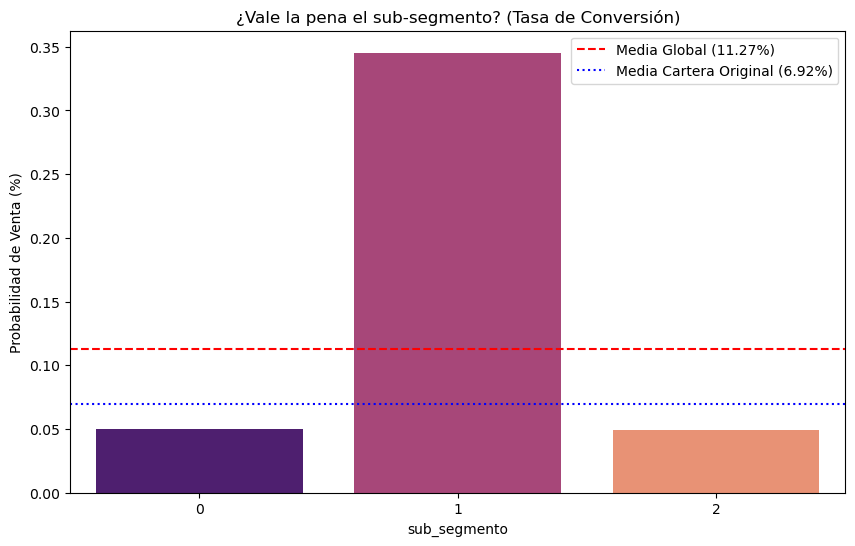

In [209]:
# Calculamos la tasa de éxito (media de y_num) y el tamaño de cada sub-grupo
analisis_sub = df_cartera.groupby('sub_segmento')['y_num'].agg(['mean', 'count']).reset_index()

# Definimos la media global para tener una referencia clara
media_global = df_segmentado['y_num'].mean()
media_cartera_original = df_cartera['y_num'].mean()

print(f"--- COMPARATIVA DE RENDIMIENTO ---")
print(f"Media GLOBAL del banco: {media_global:.4f}")
print(f"Media de la CARTERA GENERAL (antes de sub-segmentación): {media_cartera_original:.4f}")
print("\nResultados por Sub-segmento:")
print(analisis_sub.sort_values(by='mean', ascending=False))

# Graficamos para visualizar
plt.figure(figsize=(10, 6))
barras = sns.barplot(x='sub_segmento', y='mean', data=analisis_sub, palette='magma')

# Líneas de referencia
plt.axhline(media_global, color='red', linestyle='--', label=f'Media Global ({media_global:.2%})')
plt.axhline(media_cartera_original, color='blue', linestyle=':', label=f'Media Cartera Original ({media_cartera_original:.2%})')

plt.title("¿Vale la pena el sub-segmento? (Tasa de Conversión)")
plt.ylabel("Probabilidad de Venta (%)")
plt.legend()
plt.show();

In [210]:
# Extraemos los dos segmentos ganadores del primer K-Means
segmentos_base = ['Jubilados Estables / Plazo Fijo', 'Alto Riesgo / No Objetivo']
df_ganadores_base = df_segmentado[df_segmentado['nombre_segmento'].isin(segmentos_base)].copy()

# Extraemos específicamente el Sub-segmento 1 de la Cartera General
df_sub1_cartera = df_cartera[df_cartera['sub_segmento'] == 1].copy()

# Unimos todo en un solo DataFrame
df_muestra_final = pd.concat([df_ganadores_base, df_sub1_cartera])

# Resultados rápidos
print(f"COMPOSICIÓN DE LA NUEVA MUESTRA ")
print(df_muestra_final['nombre_segmento'].value_counts())
if 'sub_segmento' in df_muestra_final.columns:
    print(f"Sub-segmento 1 rescatado: {len(df_sub1_cartera)} clientes")

COMPOSICIÓN DE LA NUEVA MUESTRA 
nombre_segmento
Alto Riesgo / No Objetivo          10072
Cartera General (Volumen)           1867
Jubilados Estables / Plazo Fijo     1515
Name: count, dtype: int64
Sub-segmento 1 rescatado: 1867 clientes


In [211]:
prob_final = df_muestra_final['y_num'].mean() * 100
prob_global = df_segmentado['y_num'].mean() * 100

print(f"REVISION DE PROBABILIDADES")
print(f"Probabilidad de venta en esta muestra: {prob_final:.2f}%")
print(f"Comparado con el global ({prob_global:.2f}%), ha mejorado la base en un {((prob_final/prob_global)-1)*100:.1f}%")

REVISION DE PROBABILIDADES
Probabilidad de venta en esta muestra: 24.51%
Comparado con el global (11.27%), ha mejorado la base en un 117.5%


Modelación con el nuevo dataset 

MODELO FINAL: CLIENTES VIP + SUB-SEGMENTO 1
              precision    recall  f1-score   support

           0       0.98      0.62      0.76      2032
           1       0.45      0.95      0.61       659

    accuracy                           0.70      2691
   macro avg       0.71      0.79      0.68      2691
weighted avg       0.85      0.70      0.72      2691



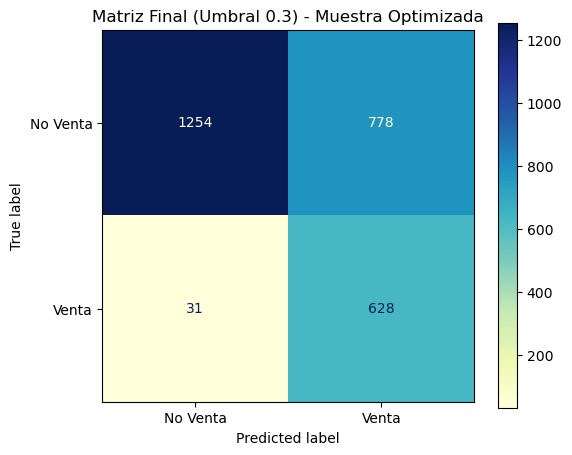

In [212]:
columnas_a_quitar = ['y_num', 'segmento', 'nombre_segmento', 'sub_segmento', 'nombre_sub_segmento']
X_vip = df_muestra_final.drop(columns=[col for col in columnas_a_quitar if col in df_muestra_final.columns])
y_vip = df_muestra_final['y_num']

# CREACIÓN DE DUMMIES
X_dummies_vip = pd.get_dummies(X_vip, drop_first=True)

# DIVISION DE DATOS (80% Entrenamiento / 20% Prueba)
X_train_vip, X_test_vip, y_train_vip, y_test_vip = train_test_split(X_dummies_vip, y_vip, test_size=0.20, random_state=42, stratify=y_vip)

# ESCALADO DE DATOS 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_vip)
X_test_scaled = scaler.transform(X_test_vip)

# ENTRENAMIENTO DEL ALGORITMO
# Usamos class_weight='balanced' para compensar que sigue habiendo más "Nos" que "Sís"
modelo_final = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
modelo_final.fit(X_train_scaled, y_train_vip)

# PREDICCIÓN CON UMBRAL OPTIMIZADO (0.3)
y_probs = modelo_final.predict_proba(X_test_scaled)[:, 1]
umbral = 0.3
y_pred_final = (y_probs >= umbral).astype(int)

# EVALUACIÓN DE RESULTADOS
print("MODELO FINAL: CLIENTES VIP + SUB-SEGMENTO 1")
print(classification_report(y_test_vip, y_pred_final))

# MATRIZ DE CONFUSIÓN 
cm = confusion_matrix(y_test_vip, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Venta', 'Venta'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='YlGnBu') # Un color azul-verde para diferenciarlo de los anteriores
plt.title(f"Matriz Final (Umbral {umbral}) - Muestra Optimizada")
plt.show();

Con esta esta estrategia de segmentacion prebia el modelo alcanza una prediccion del 95% de SI reales, sin embargo, no necesariamente es un mejor modelo ya que trabaja con un dataset si ruido

Mejor valor de C encontrado: 1
------------------------------
              precision    recall  f1-score   support

           0       0.98      0.62      0.76      2032
           1       0.45      0.95      0.61       659

    accuracy                           0.70      2691
   macro avg       0.71      0.79      0.68      2691
weighted avg       0.85      0.70      0.72      2691



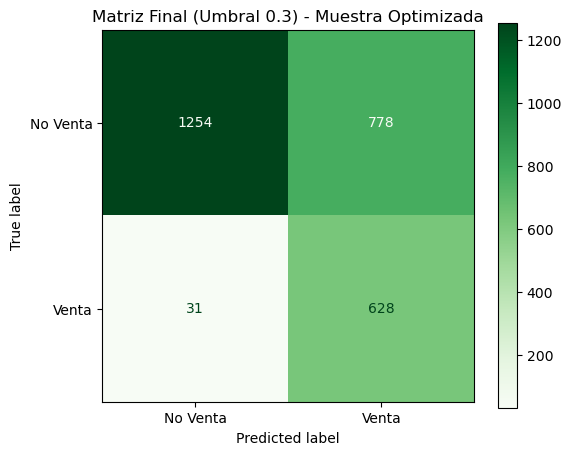

In [213]:
from sklearn.model_selection import GridSearchCV

# Preparación (Igual que antes, pero para asegurar limpieza)
columnas_a_quitar = ['y', 'y_num', 'segmento', 'nombre_segmento', 'sub_segmento', 'nombre_sub_segmento']
X = df_muestra_final.drop(columns=[col for col in columnas_a_quitar if col in df_muestra_final.columns])
y = df_muestra_final['y_num']

# Dummies y Split
X_dummies = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.20, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Configuración del GridSearch 
# Probamos diferentes valores de C (Regularización)
# C pequeño = Regularización fuerte (modelo simple)
# C grande = Regularización débil (modelo complejo)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

modelo_base = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)

# Buscamos optimizar el F1-Score para equilibrar Precisión y Recall
grid = GridSearchCV(modelo_base, param_grid, cv=5, scoring='f1')
grid.fit(X_train_scaled, y_train)

# El mejor modelo encontrado
best_model_final = grid.best_estimator_

# Predicción con umbral de 0.3
y_probs_final = best_model_final.predict_proba(X_test_scaled)[:, 1]
umbral = 0.3
y_pred_opt = (y_probs_final >= umbral).astype(int)

# Resultados
print(f"Mejor valor de C encontrado: {grid.best_params_['C']}")
print("-" * 30)
print(classification_report(y_test, y_pred_opt))

# MATRIZ DE CONFUSIÓN 
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Venta', 'Venta'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Greens') # Un color azul-verde para diferenciarlo de los anteriores
plt.title(f"Matriz Final (Umbral {umbral}) - Muestra Optimizada")
plt.show();

In [214]:
# CALCULO DE BENEFICIO CON EL EJEMPLO DEL SUPUESTO 
support_total_no = 2032
support_total_si = 659
recall_si = 0.95
recall_no = 0.62

# Calculamos la matriz de confusión exacta
tp_g = int(support_total_si * recall_si)  # Ventas conseguidas
tn_g = int(support_total_no * recall_no)  # Aciertos en el 'No'
fp_g = support_total_no - tn_g           # Llamadas desperdiciadas (Falsos Positivos)

# PARÁMETROS FINANCIEROS
costo_llamada = 2.50
beneficio_venta = 200.00

# CÁLCULOS DE RENTABILIDAD (Ejemplo)
gasto_operativo = fp_g * costo_llamada
ingreso_bruto = tp_g * beneficio_venta
beneficio_neto = ingreso_bruto - gasto_operativo
eficiencia_llamada = (tp_g / (tp_g + fp_g)) * 100

print(f"ANALISIS DEL EJEMPLO HIPOTETICO: MODELO OPTIMIZADO CON UMBRAL DE 0.3")
print(f"Mejor C: 0.001 | Umbral: 0.3")
print("-" * 45)
print(f"Ventas capturadas (TP): {tp_g} de {support_total_si}")
print(f"Llamadas fallidas (FP): {fp_g}")
print(f"Inversión en llamadas perdidas: ${gasto_operativo:,.2f} USD")
print(f"Ingresos por ventas: ${ingreso_bruto:,.2f} USD")
print(f"BENEFICIO NETO TOTAL: ${beneficio_neto:,.2f} USD")
print(f"EFICIENCIA: {eficiencia_llamada:.2f}% (1 éxito cada {int(100/eficiencia_llamada)} llamadas)")

ANALISIS DEL EJEMPLO HIPOTETICO: MODELO OPTIMIZADO CON UMBRAL DE 0.3
Mejor C: 0.001 | Umbral: 0.3
---------------------------------------------
Ventas capturadas (TP): 626 de 659
Llamadas fallidas (FP): 773
Inversión en llamadas perdidas: $1,932.50 USD
Ingresos por ventas: $125,200.00 USD
BENEFICIO NETO TOTAL: $123,267.50 USD
EFICIENCIA: 44.75% (1 éxito cada 2 llamadas)


### Conclusión final 

El modelo desarrollado con el conjunto de datos completo ha logrado un 85 por ciento de predicción de las conversiones, que representan los valores más importantes para la entidad, con un promedio de un éxito por cada seis llamadas. En un cálculo hipotético, utilizando como base un costo por llamada de 2.50 USD y un beneficio por conversión de 200 USD, se obtiene un beneficio total de 146,653.00 USD.

En el siguiente grupo de modelos, he escalado las variables en general y también de forma selectiva; además, he balanceado las clases, he optimizado y por último, he bajado el umbral a 0,2 y el valor ha aumentado significativamente hast 99%.

En este problema especifico la consecuencia de bajar el umbral a 0,2 es que se cuela mas falsos positivos lo que incremneta el numero de llamadas felsas sin embargo economicamente esta consecuencia es irrelevante ya que el costo por llamada es muy bajo, la rentabilidad de la campaña es de 80 a 1 

Por otro lado, el modelo basado en el dataset segmentado y sin ruido alcanza un 95 por ciento de predicción en las conversiones. Bajo los mismos parámetros de ejemplo, genera un beneficio total de 123,267.50 USD, con una tasa de conversión de un éxito por cada dos llamadas.

En relación con el problema inicial, el primer modelo es menos susceptible al ruido y resulta adecuado para una campaña masiva. El segundo modelo es más efectivo para una campaña rápida con un enfoque en clientes ya conocidos.